In [4]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [3]:
yankees = pd.read_csv("yankees_2000-2026.csv")
yankees.head(10)

,Name,Team,G,PA,HR,R,RBI,SB,BB%,K%,AVG,OBP,SLG
0,José Molina,NYY,181,523,5,56,38,0,0.053537,0.177820,0.230932,0.281250,0.317797
1,Russell Martin,NYY,258,961,39,107,118,14,0.107180,0.183143,0.224076,0.317328,0.405244
2,Jose Trevino,NYY,244,755,23,80,86,3,0.056954,0.165563,0.229672,0.278884,0.360913
3,Brett Gardner,NYY,1688,6614,139,943,578,274,0.105685,0.188237,0.256231,0.341635,0.398117
4,Chris Stewart,NYY,165,500,5,43,38,6,0.080000,0.142000,0.219178,0.291242,0.285388
5,Kyle Higashioka,NYY,314,923,40,94,121,0,0.055255,0.264355,0.209790,0.253261,0.393939
6,Austin Wells,NYY,327,1159,44,120,152,7,0.089733,0.242450,0.210578,0.284848,0.390793
7,Brian McCann,NYY,405,1565,69,181,227,1,0.088179,0.174441,0.235421,0.313099,0.418287
8,Francisco Cervelli,NYY,250,785,10,88,92,6,0.081529,0.171975,0.277616,0.348446,0.380814
9,Anthony Volpe,NYY,517,2044,53,235,205,77,0.076810,0.249022,0.224259,0.287678,0.374663


In [4]:
yankees["OPS"] = yankees["OBP"]+ yankees["SLG"].copy()
yankees["Walk_to_K"]= yankees["BB%"] / yankees["K%"].copy()
yankees["HR_efficiency"]=yankees["HR"] / yankees["PA"].copy()
yankees.head(10)

,Name,Team,G,PA,HR,R,RBI,SB,BB%,K%,AVG,OBP,SLG,OPS,Walk_to_K,HR_efficiency
0,José Molina,NYY,181,523,5,56,38,0,0.053537,0.177820,0.230932,0.281250,0.317797,0.599047,0.301075,0.009560
1,Russell Martin,NYY,258,961,39,107,118,14,0.107180,0.183143,0.224076,0.317328,0.405244,0.722572,0.585227,0.040583
2,Jose Trevino,NYY,244,755,23,80,86,3,0.056954,0.165563,0.229672,0.278884,0.360913,0.639797,0.344000,0.030464
3,Brett Gardner,NYY,1688,6614,139,943,578,274,0.105685,0.188237,0.256231,0.341635,0.398117,0.739752,0.561446,0.021016
4,Chris Stewart,NYY,165,500,5,43,38,6,0.080000,0.142000,0.219178,0.291242,0.285388,0.576630,0.563380,0.010000
5,Kyle Higashioka,NYY,314,923,40,94,121,0,0.055255,0.264355,0.209790,0.253261,0.393939,0.647200,0.209016,0.043337
6,Austin Wells,NYY,327,1159,44,120,152,7,0.089733,0.242450,0.210578,0.284848,0.390793,0.675642,0.370107,0.037964
7,Brian McCann,NYY,405,1565,69,181,227,1,0.088179,0.174441,0.235421,0.313099,0.418287,0.731386,0.505495,0.044089
8,Francisco Cervelli,NYY,250,785,10,88,92,6,0.081529,0.171975,0.277616,0.348446,0.380814,0.729260,0.474074,0.012739
9,Anthony Volpe,NYY,517,2044,53,235,205,77,0.076810,0.249022,0.224259,0.287678,0.374663,0.662341,0.308448,0.025930


In [5]:
df= yankees
metrics= ["AVG", "OBP", "OPS", "HR", "K%", "BB%"]
mean_vs_med= pd.DataFrame({'Mean':df[metrics].mean(), 'Median': df[metrics].median()})
print("---Mean vs Median---")
print("\n---Skewness---")
print(df[metrics].skew())

---Mean vs Median---

---Skewness---
AVG    1.746990
OBP    0.864826
OPS    1.057916
HR     5.008901
K%     1.916318
BB%    3.613116
dtype: float64


In [6]:
df= yankees
yankees_descriptives= df[metrics].describe().T[['min', '25%','50%','75%','max','std']]
yankees_descriptives['IQR']=yankees_descriptives['75%']- yankees_descriptives['25%']
print("---Range Descriptives---")
print(yankees_descriptives[['min','max','std','IQR']])

---Range Descriptives---
     min         max        std        IQR
AVG  0.0    1.000000   0.140026   0.139549
OBP  0.0    1.000000   0.159081   0.132955
OPS  0.0    3.000000   0.358811   0.364124
HR   0.0  385.000000  42.661853  10.000000
K%   0.0    1.000000   0.210521   0.154318
BB%  0.0    0.666667   0.084742   0.100000


In [8]:
yankees_temp_PA = yankees[yankees["PA"]>= 100].copy()
yankees_temp_PA.head(5)

,Name,Team,G,PA,HR,R,RBI,SB,BB%,K%,AVG,OBP,SLG,OPS,Walk_to_K,HR_efficiency
0,José Molina,NYY,181,523,5,56,38,0,0.053537,0.177820,0.230932,0.281250,0.317797,0.599047,0.301075,0.009560
1,Russell Martin,NYY,258,961,39,107,118,14,0.107180,0.183143,0.224076,0.317328,0.405244,0.722572,0.585227,0.040583
2,Jose Trevino,NYY,244,755,23,80,86,3,0.056954,0.165563,0.229672,0.278884,0.360913,0.639797,0.344000,0.030464
3,Brett Gardner,NYY,1688,6614,139,943,578,274,0.105685,0.188237,0.256231,0.341635,0.398117,0.739752,0.561446,0.021016
4,Chris Stewart,NYY,165,500,5,43,38,6,0.080000,0.142000,0.219178,0.291242,0.285388,0.576630,0.563380,0.010000


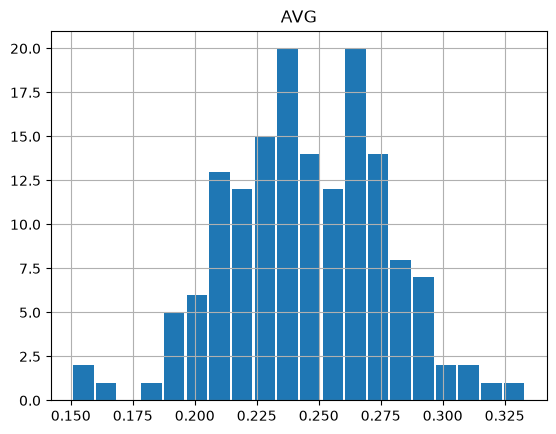

In [9]:
yankees_temp_PA.hist(column="AVG", bins= 20, rwidth=0.9)
plt.show()

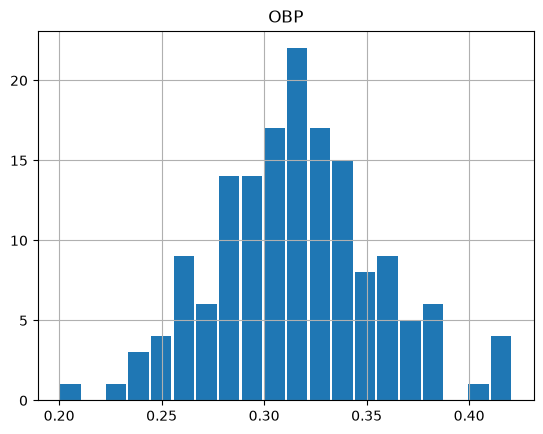

In [10]:
yankees_temp_PA.hist(column="OBP", bins= 20, rwidth=0.9)
plt.show()

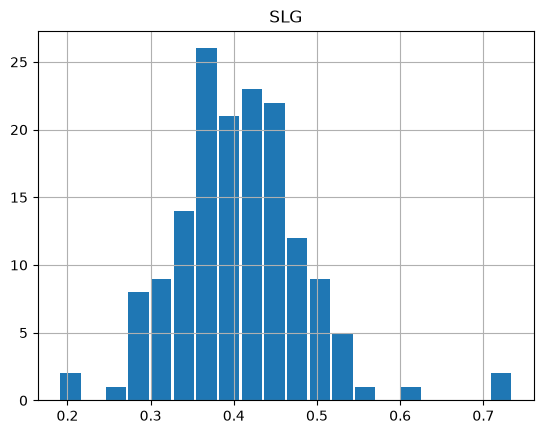

In [11]:
yankees_temp_PA.hist(column="SLG", bins= 20, rwidth=0.9)
plt.show()

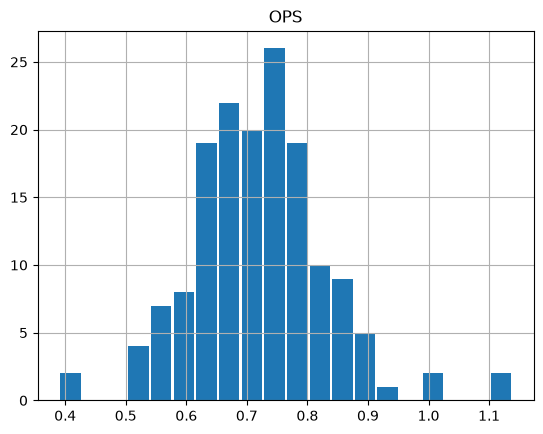

In [12]:
yankees_temp_PA.hist(column="OPS", bins= 20, rwidth=0.9)
plt.show()

In [13]:
yankees_compare=pd.DataFrame({'Raw Data(All Players)': yankees[["AVG", "OBP","SLG","OPS"]].mean(), 
                             'Threshold(PA>=100)': yankees_temp_PA[["AVG","OBP","SLG","OPS"]].mean()})
print(yankees_compare)

     Raw Data(All Players)  Threshold(PA>=100)
AVG               0.192517            0.244924
OBP               0.257428            0.315318
SLG               0.301058            0.406924
OPS               0.558486            0.722242


In [14]:
pa_threshold= 300
yankees_bench= yankees[yankees["PA"] < pa_threshold].copy()
yankees_bench.head(5)

,Name,Team,G,PA,HR,R,RBI,SB,BB%,K%,AVG,OBP,SLG,OPS,Walk_to_K,HR_efficiency
18,John Ryan Murphy,NYY,115,284,4,31,24,0,0.059859,0.260563,0.267176,0.310954,0.374046,0.685000,0.229730,0.014085
19,J.C. Escarra,NYY,72,190,2,13,18,1,0.089474,0.168421,0.195266,0.268421,0.301775,0.570196,0.531250,0.010526
27,Marwin Gonzalez,NYY,86,207,6,20,18,3,0.067633,0.260870,0.184783,0.254902,0.320652,0.575554,0.259259,0.028986
28,Todd Frazier,NYY,66,241,11,33,32,0,0.145228,0.224066,0.221649,0.365145,0.422680,0.787826,0.648148,0.045643
29,Andy Pettitte,NYY,282,44,0,1,3,0,0.000000,0.409091,0.125000,0.125000,0.175000,0.300000,0.000000,0.000000


In [15]:
yankees_starter= yankees[yankees["PA"] >= pa_threshold].copy()
yankees_starter.head(5)

,Name,Team,G,PA,HR,R,RBI,SB,BB%,K%,AVG,OBP,SLG,OPS,Walk_to_K,HR_efficiency
0,José Molina,NYY,181,523,5,56,38,0,0.053537,0.177820,0.230932,0.281250,0.317797,0.599047,0.301075,0.009560
1,Russell Martin,NYY,258,961,39,107,118,14,0.107180,0.183143,0.224076,0.317328,0.405244,0.722572,0.585227,0.040583
2,Jose Trevino,NYY,244,755,23,80,86,3,0.056954,0.165563,0.229672,0.278884,0.360913,0.639797,0.344000,0.030464
3,Brett Gardner,NYY,1688,6614,139,943,578,274,0.105685,0.188237,0.256231,0.341635,0.398117,0.739752,0.561446,0.021016
4,Chris Stewart,NYY,165,500,5,43,38,6,0.080000,0.142000,0.219178,0.291242,0.285388,0.576630,0.563380,0.010000


In [16]:
yankees_starter.describe()

,G,PA,HR,R,RBI,SB,BB%,K%,AVG,OBP,SLG,OPS,Walk_to_K,HR_efficiency
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,393.021053,1535.000000,56.031579,204.789474,197.000000,25.547368,0.089280,0.194163,0.249963,0.322170,0.416812,0.738983,0.486003,0.033001
std,379.020490,1662.825153,70.914310,245.949610,226.746085,46.107130,0.030884,0.055373,0.028375,0.034934,0.063151,0.092448,0.200271,0.015060
min,83.000000,313.000000,0.000000,37.000000,15.000000,0.000000,0.034188,0.086262,0.159145,0.253261,0.279635,0.548019,0.208850,0.000000
25%,167.500000,503.000000,13.000000,63.000000,61.000000,3.000000,0.069689,0.156137,0.231750,0.295022,0.374174,0.665524,0.344414,0.021105
50%,258.000000,923.000000,29.000000,108.000000,113.000000,7.000000,0.088083,0.184971,0.250396,0.319879,0.413793,0.735179,0.443662,0.033416
75%,470.500000,1806.000000,64.500000,240.000000,227.500000,31.000000,0.107129,0.224123,0.269766,0.340262,0.457045,0.795874,0.593960,0.041767
max,2109.000000,9716.000000,385.000000,1437.000000,1096.000000,274.000000,0.180926,0.387226,0.309033,0.419355,0.611253,1.022178,1.148148,0.073152


In [17]:
high_walks= yankees_starter[(yankees_starter['OBP'] >=0.330) & (yankees_starter['AVG']<= 0.250)][['Name','PA','AVG','OBP','BB%', 'HR']].sort_values(by='OBP', ascending= False)
high_walks.head()

,Name,PA,AVG,OBP,BB%,HR
361,Nick Johnson,1023,0.248514,0.377581,0.145650,33
15,Robin Ventura,888,0.248663,0.359322,0.146396,36
372,Mark Teixeira,4098,0.247871,0.343338,0.116154,206
350,Aaron Hicks,2424,0.231666,0.337329,0.134488,81
35,Curtis Granderson,2148,0.244755,0.334581,0.111732,115


In [18]:
low_strikeout = yankees_starter[(yankees_starter['HR'] >=25) & (yankees_starter['K%']<= 0.15)][['Name','PA','HR','K%','AVG', 'OPS']].sort_values(by='HR', ascending= False)
low_strikeout.head()

,Name,PA,HR,K%,AVG,OPS
347,Robinson Canó,5791,204,0.118978,0.309033,0.859627
362,Derek Jeter,9716,197,0.140696,0.306999,0.805672
376,Hideki Matsui,3820,140,0.126963,0.291816,0.852399
377,Bernie Williams,4128,136,0.129118,0.288333,0.837434
74,Didi Gregorius,2658,97,0.135064,0.269089,0.758963


In [19]:
yankees['Role']= np.where(yankees['PA'] >= pa_threshold, 'Starter', 'Bench').copy()
yankees.groupby('Role')[['AVG','OBP','SLG','OPS','HR_efficiency']].mean()

,AVG,OBP,SLG,OPS,HR_efficiency
Role,,,,,
Bench,0.173233,0.235695,0.262201,0.497895,0.014758
Starter,0.249963,0.322170,0.416812,0.738983,0.033001


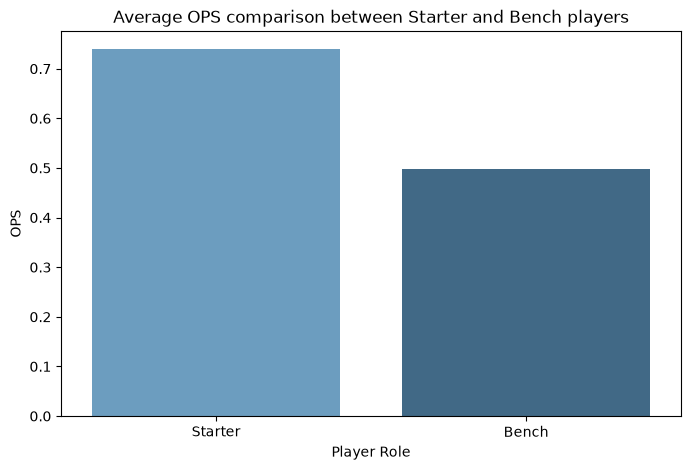

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data=yankees, x = 'Role', y='OPS', errorbar=None, hue= 'Role',palette='Blues_d', legend= False)
plt.title('Average OPS comparison between Starter and Bench players')
plt.xlabel('Player Role')
plt.ylabel('OPS')
plt.show()

In [21]:
yankees_HR = yankees[yankees["HR"]>5].sort_values(by= "HR", ascending = False).reset_index().copy()
yankees_HR.head(10)

,index,Name,Team,G,PA,HR,R,RBI,SB,BB%,K%,AVG,OBP,SLG,OPS,Walk_to_K,HR_efficiency,Role
0,351,Aaron Judge,NYY,1204,5263,385,916,868,70,0.163215,0.273798,0.291271,0.410925,0.611253,1.022178,0.596114,0.073152,Starter
1,363,Alex Rodriguez,NYY,1509,6520,351,1012,1096,152,0.119479,0.198160,0.283306,0.377761,0.522503,0.900264,0.602941,0.053834,Starter
2,21,Jorge Posada,NYY,1537,6065,240,764,920,18,0.132729,0.202968,0.276926,0.379225,0.482826,0.862051,0.653940,0.039571,Starter
3,375,Jason Giambi,NYY,897,3693,209,515,604,9,0.167614,0.191172,0.260395,0.404008,0.521132,0.925139,0.876771,0.056594,Starter
4,372,Mark Teixeira,NYY,958,4098,206,533,622,13,0.116154,0.182284,0.247871,0.343338,0.478705,0.822043,0.637216,0.050268,Starter
5,347,Robinson Canó,NYY,1374,5791,204,799,822,38,0.060439,0.118978,0.309033,0.355129,0.504498,0.859627,0.507983,0.035227,Starter
6,362,Derek Jeter,NYY,2109,9716,197,1437,970,272,0.083265,0.140696,0.306999,0.373586,0.432086,0.805672,0.591807,0.020276,Starter
7,374,Giancarlo Stanton,NYY,764,3153,189,375,511,7,0.102759,0.300666,0.244708,0.325079,0.490850,0.815930,0.341772,0.059943,Starter
8,376,Hideki Matsui,NYY,916,3820,140,536,597,12,0.108901,0.126963,0.291816,0.370021,0.482378,0.852399,0.857732,0.036649,Starter
9,3,Brett Gardner,NYY,1688,6614,139,943,578,274,0.105685,0.188237,0.256231,0.341635,0.398117,0.739752,0.561446,0.021016,Starter


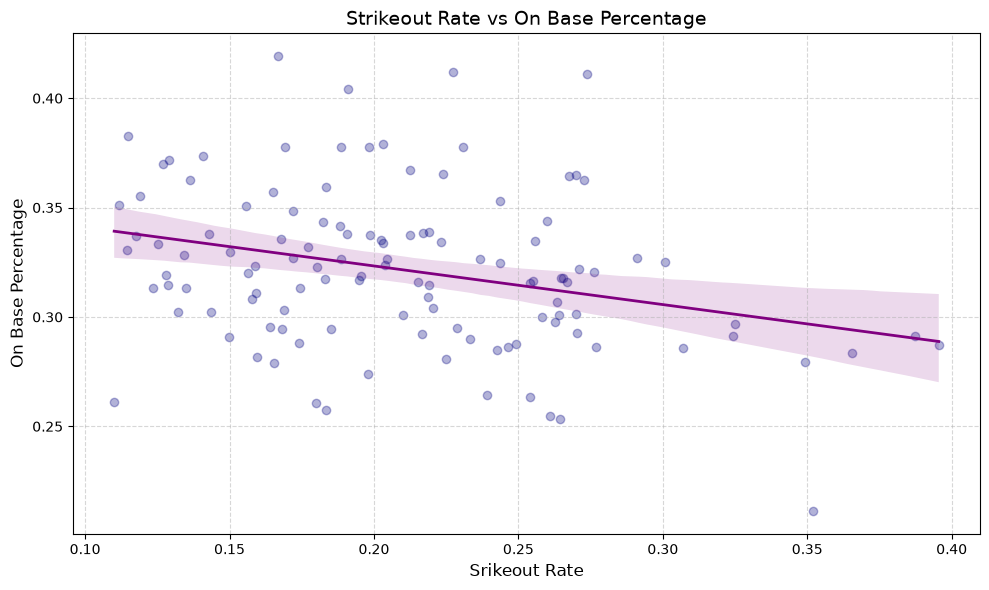

In [22]:
plt.figure(figsize=(10,6))
sns.regplot(data=yankees_HR,x="K%", y="OBP", scatter_kws={"alpha":0.3,"color":"navy"}, 
            line_kws={"color":"purple", "linewidth":2})
plt.title("Strikeout Rate vs On Base Percentage", fontsize=14)
plt.xlabel("Srikeout Rate", fontsize=12)
plt.ylabel("On Base Percentage", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [23]:
kvsobp= yankees_HR["K%"].corr(yankees_HR["OBP"])
print(f"correlation between K% and OBP:{kvsobp:.3f}")

correlation between K% and OBP:-0.300


In [24]:
kvsobp2=yankees_starter["K%"].corr(yankees_starter["OBP"])
print(f"Correlation of K% + OBP controlled for PA:{kvsobp2:.3f}")

Correlation of K% + OBP controlled for PA:-0.173


In [26]:
slgvshr= yankees_starter["HR"].corr(yankees_starter["SLG"])
slgvsavg=yankees_starter["AVG"].corr(yankees_starter["SLG"])
print(f"HR vs SLG Correlation is: {slgvshr:.3f}")
print(f"AVG vs SLG Correlation is:{slgvsavg:.3f}")

HR vs SLG Correlation is: 0.655
AVG vs SLG Correlation is:0.550


In [27]:
top_hr= yankees.sort_values(by="HR", ascending = False).head(10).copy()

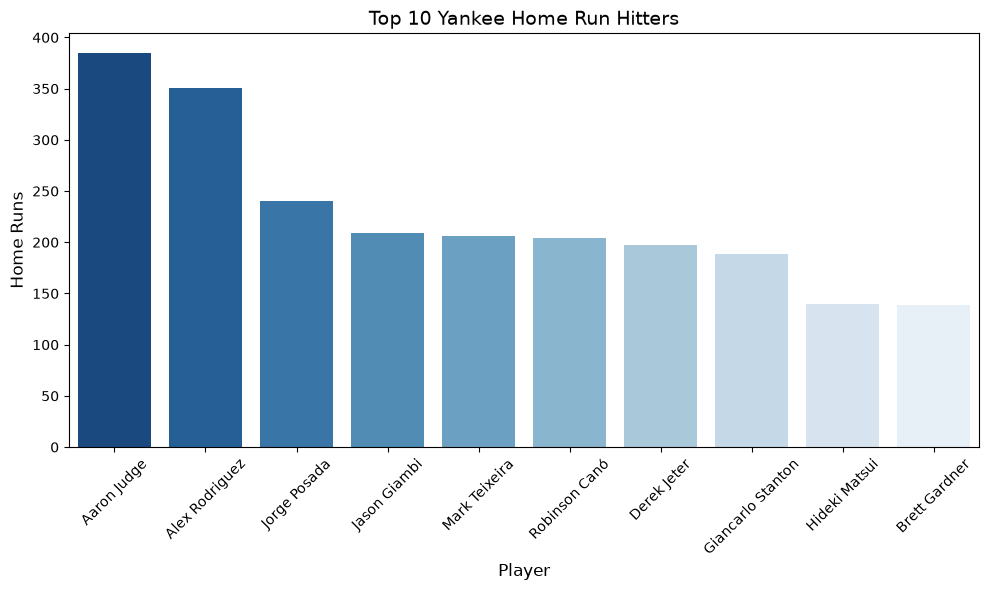

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_hr, x = "Name", y= "HR", hue="Name", palette= "Blues_r", legend= False)
plt.title("Top 10 Yankee Home Run Hitters", fontsize=14)
plt.xlabel("Player", fontsize=12)
plt.ylabel("Home Runs", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
import statsmodels.formula.api as smf
OPS_pred = smf.ols(formula= "R ~ OPS + PA", data= yankees_starter).fit()
print(OPS_pred.summary())

                            OLS Regression Results                            
Dep. Variable:                      R   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     3280.
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           2.99e-86
Time:                        20:47:43   Log-Likelihood:                -453.94
No. Observations:                  95   AIC:                             913.9
Df Residuals:                      92   BIC:                             921.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -110.9472     26.751     -4.147      0.0

In [30]:
Plate_pred= smf.ols(formula= "Q('R') ~ Q('BB%') + Q('K%') + AVG + PA", data= yankees_starter).fit()
print(Plate_pred.summary())

                            OLS Regression Results                            
Dep. Variable:                 Q('R')   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     1642.
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           3.56e-83
Time:                        20:47:43   Log-Likelihood:                -452.87
No. Observations:                  95   AIC:                             915.7
Df Residuals:                      90   BIC:                             928.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -146.1113     44.087     -3.314      0.0

In [2]:
yankees_by_szn= pd.read_csv("yankees_by_szn.csv")
yankees_by_szn.head(20)

,Season,Name,Team,G,PA,HR,R,RBI,SB,BB%,K%,AVG,OBP,SLG
0,2011,Brett Gardner,NYY,159,588,7,87,36,49,0.102041,0.158163,0.258824,0.344828,0.368627
1,2010,Brett Gardner,NYY,150,569,5,97,47,47,0.138840,0.177504,0.276730,0.382979,0.379455
2,2001,Alfonso Soriano,NYY,158,614,18,77,73,43,0.047231,0.203583,0.268293,0.304419,0.432056
3,2002,Alfonso Soriano,NYY,156,741,39,128,102,41,0.031039,0.211876,0.300287,0.332432,0.547414
4,2014,Jacoby Ellsbury,NYY,149,635,16,71,70,39,0.077165,0.146457,0.271304,0.328076,0.419130
5,2001,Chuck Knoblauch,NYY,137,600,9,66,44,38,0.096667,0.121667,0.249520,0.339496,0.351248
6,2003,Alfonso Soriano,NYY,156,734,38,114,91,35,0.051771,0.177112,0.290323,0.337875,0.524927
7,2006,Derek Jeter,NYY,154,715,14,118,97,34,0.096503,0.142657,0.343499,0.416667,0.483146
8,2002,Derek Jeter,NYY,157,730,18,124,75,32,0.100000,0.156164,0.296584,0.372765,0.420807
9,2025,Jazz Chisholm Jr.,NYY,130,531,31,75,80,31,0.109228,0.278719,0.242424,0.332075,0.480519


In [13]:
yanks_2009= yankees_by_szn[yankees_by_szn['Season'] == 2009].copy()
rs= yanks_2009['R'].sum()
ra= 753
pyth_win_pct= (rs**2)/ ((rs**2) + (ra**2))
exp_wins= pyth_win_pct * 162
print(f"Estimated 2009 Runs Scored (rs): {rs:.0f}")
print(f"Estimated 2009 Runs Allowed (ra): {ra}")
print(f"Estimated 2009 Pythagorean Win %: {pyth_win_pct:.3f}")
print(f"Estimated 2009 Expected Wins: {exp_wins:.1f}")

Estimated 2009 Runs Scored (rs): 913
Estimated 2009 Runs Allowed (ra): 753
Estimated 2009 Pythagorean Win %: 0.595
Estimated 2009 Expected Wins: 96.4


In [8]:
import pandas as pd

season_summary = yankees_by_szn.groupby("Season")["R"].sum().reset_index()
season_summary.rename(columns={"R": "RS"}, inplace=True)

real_ra = {
    2000: 814,
    2001: 713,
    2002: 697,
    2003: 716,
    2004: 808,
    2005: 789,
    2006: 767,
    2007: 777,
    2008: 727,
    2009: 753, 
    2010: 693,
    2011: 657,
    2012: 668,
    2013: 671,
    2014: 664,
    2015: 698,
    2016: 702,
    2017: 660,
    2018: 669,
    2019: 739,
    2020: 270, 
    2021: 669,
    2022: 567,
    2023: 698,
    2024: 668,
    2025: 685,
    2026: 449  
}

season_summary["RA"] = season_summary["Season"].map(real_ra)

season_summary["pyth_win_pct"] = (season_summary["RS"] ** 2) / (
    (season_summary["RS"] ** 2) + (season_summary["RA"] ** 2)
)

season_summary["exp_wins"] = season_summary["pyth_win_pct"] * 162

season_summary["games_played"] = 162
season_summary.loc[season_summary["Season"] == 2020, "games_played"] = 60
season_summary.loc[season_summary["Season"] == 2026, "games_played"] = 118

season_summary["exp_wins"] = season_summary["pyth_win_pct"] * season_summary["games_played"]

season_summary = season_summary.sort_values(by="exp_wins", ascending=False).reset_index(drop=True)

print("--- Best Season (Actual RA) ---")
print(season_summary.head(1))

print("\n--- Full Season Rankings ---")
print(season_summary)

--- Best Season (Actual RA) ---
   Season   RS   RA  pyth_win_pct    exp_wins  games_played
0    2022  807  567      0.669501  108.459151           162

--- Full Season Rankings ---
    Season   RS   RA  pyth_win_pct    exp_wins  games_played
0     2022  807  567      0.669501  108.459151           162
1     2011  867  657      0.635228  102.906877           162
2     2017  857  660      0.627708  101.688680           162
3     2002  894  697      0.621952  100.756185           162
4     2019  942  739      0.619026  100.282157           162
5     2018  849  669      0.616933   99.943136           162
6     2007  968  777      0.608160   98.521884           162
7     2010  859  693      0.605749   98.131334           162
8     2025  849  685      0.605702   98.123707           162
9     2003  877  716      0.600045   97.207330           162
10    2024  815  668      0.598159   96.901749           162
11    2009  913  753      0.595161   96.416035           162
12    2006  929  767     

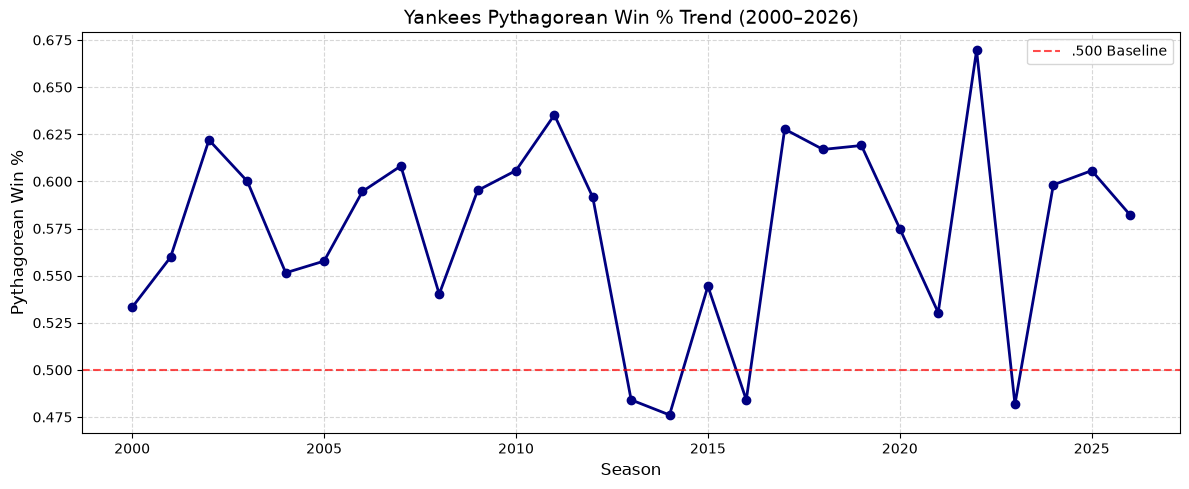

In [10]:
import matplotlib.pyplot as plt
chronological_szns = season_summary.sort_values("Season")

plt.figure(figsize=(12, 5))
plt.plot(chronological_szns["Season"], chronological_szns["pyth_win_pct"], marker="o", color="navy", linewidth=2)

plt.title("Yankees Pythagorean Win % Trend (2000–2026)", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Pythagorean Win %", fontsize=12)
plt.axhline(0.500, color="red", linestyle="--", alpha=0.7, label=".500 Baseline")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()